# 1. Imports

In [63]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import math
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn import __version__ as sklearn_version

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import RidgeCV
import statsmodels.api as sm

from sklearn.svm import LinearSVR # Linear Support Vector Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [64]:
!brew reinstall libomp

⠋ JSON API formula.jws.json                        [Downloading  31.7MB/-------]
⠋ JSON API formula_tap_migrations.jws.json         [Downloading   2.1KB/-------]
⠋ JSON API cask.jws.json                           [Downloading  15.1MB/-------]
⠋ JSON API cask_tap_migrations.jws.json            [Downloading   2.4KB/-------]⠋ JSON API formula.jws.json                        [Downloading  31.7MB/-------]
⠋ JSON API formula_tap_migrations.jws.json         [Downloading   2.1KB/-------]
⠋ JSON API cask.jws.json                           [Downloading  15.1MB/-------]
⠋ JSON API cask_tap_migrations.jws.json            [Downloading   2.4KB/-------]⠙ JSON API formula.jws.json                        [Downloading  31.7MB/-------]
⠙ JSON API formula_tap_migrations.jws.json         [Downloading   2.1KB/-------]
⠙ JSON API cask.jws.json                           [Downloading  15.1MB/-------]
⠙ JSON API cask_tap_migrations.jws.json            [Downloading   2.4KB/-------]⠙ JSON API formula.jws.json    

In [65]:
#!pip uninstall xgboost - ran this in terminal because it requires Y/n prompt
#
!pip uninstall -y xgboost
!pip install xgboost
# Successfully installed xgboost-3.1.2


Found existing installation: xgboost 3.1.2
Uninstalling xgboost-3.1.2:
  Successfully uninstalled xgboost-3.1.2
  Using cached xgboost-3.1.2-py3-none-macosx_10_15_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.2-py3-none-macosx_10_15_x86_64.whl (2.4 MB)


In [66]:
#!pip install xgboost
import xgboost as xgb

Had to do a fair amount of work in Terminal before I could successfully import xgboost. a few notes

Homebrew installed OpenMP here:
- /usr/local/Cellar/libomp/21.1.7/lib/libomp.dylib
- /usr/local/opt/libomp/lib

Created a symlink (shortcut) inside Anaconda pointing to the real file:
ln -s /usr/local/opt/libomp/lib/libomp.dylib /Users/grace/anaconda3/lib/libomp.dylib


# 2. Group Split - Investigate how features do or do not influence MMR coverage

## 2a. Load data


In [68]:
os.chdir('/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/group_split/')

In [69]:
df = pd.read_csv('X_train.csv') 
feature_names = df.columns.to_list()
feature_names

['% Low Birthweight',
 '# Primary Care Physicians',
 'Primary Care Physicians Rate',
 '% Vaccinated Flu',
 '% Children in Poverty',
 'Infant Mortality Rate',
 '# Uninsured Children',
 '% Uninsured Children',
 '# Food Insecure',
 '% Food Insecure',
 'Segregation index_b',
 'Other Primary Care Provider Rate',
 'Median Household Income',
 '% Enrolled in Free or Reduced Lunch',
 'Population',
 '% Female',
 '% Rural',
 'year',
 '% Broadband Access',
 '% Less Than 18 Years of Age',
 'live_births',
 'kin_DTP_cov',
 'kin_HepA_cov',
 'kin_HepB_cov',
 'kin_polio_cov',
 'kin_varic_cov',
 'Estimated hesitant',
 'Estimated hesitant or unsure',
 'Estimated strongly hesitant',
 'Social Vulnerability Index (SVI)',
 'CVAC level of concern for vaccination rollout',
 'other_pc_provider_ratio_numerator',
 'other_pc_provider_ratio_denominator',
 'seg_missing_bool',
 'OH__Low Vulnerability',
 'OH__Moderate Vulnerability',
 'OH__Very High Vulnerability',
 'OH__Very Low Vulnerability',
 'OH__Moderate Concern'

In [42]:
def csv_to_numpy_array_with_pandas(filename):
    df = pd.read_csv(filename) 
    print(f"\nDataFrame before conversion:")
    #print(f"Dtypes:\n{df.dtypes}\n")
    print(f"NaN count per column:\n{df.isna().sum()}")
    print(f"Total NaN: {df.isna().sum().sum()}")
    
    array = df.to_numpy()
    print(f"\nArray after conversion:")
    print(f"  Shape: {array.shape}\n")
    #print(f"  Dtype: {array.dtype}")
    print(f"  NaN count: {np.isnan(array).sum()}")
    return array

In [43]:
file_names = ["X_train.csv", 
              "y_train.csv", 
              "X_test.csv", 
              "y_test.csv"]

In [44]:
# Unpack data from csvs 
X_train = csv_to_numpy_array_with_pandas(file_names[0])
y_train = csv_to_numpy_array_with_pandas(file_names[1])
X_test = csv_to_numpy_array_with_pandas(file_names[2])
y_test = csv_to_numpy_array_with_pandas(file_names[3])


DataFrame before conversion:
NaN count per column:
% Low Birthweight                                0
# Primary Care Physicians                        0
Primary Care Physicians Rate                     0
% Vaccinated Flu                                 0
% Children in Poverty                            0
Infant Mortality Rate                            0
# Uninsured Children                             0
% Uninsured Children                             0
# Food Insecure                                  0
% Food Insecure                                  0
Segregation index_b                              0
Other Primary Care Provider Rate                 0
Median Household Income                          0
% Enrolled in Free or Reduced Lunch              0
Population                                       0
% Female                                         0
% Rural                                          0
% Broadband Access                               0
% Less Than 18 Years of Age   

In [45]:
# specify cross validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=1)


## 2c. Models

## LinearRegression()

In [11]:
# create pipeline and fit to data
lr1 = Pipeline([
    ("regressor", LinearRegression())
])
scores = cross_val_score(lr1, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

In [12]:
# Evaluate the model
rmse_scores = np.sqrt(-scores)
print("RMSE scores for each fold:",rmse_scores)
#print(f"R squared of model is: {lr1.score(X_train, y_train)}")
print("Mean RMSE across all folds:", rmse_scores.mean())
print("Standard deviation of RMSE across all folds:", rmse_scores.std())

RMSE scores for each fold: [0.04767922 0.03761684 0.0366505  0.04319147 0.05546036]
Mean RMSE across all folds: 0.044119676568365025
Standard deviation of RMSE across all folds: 0.00693135630704666


In [13]:
lr1.fit(X_train, y_train)


Pipeline(steps=[('regressor', LinearRegression())])

In [14]:
# check for missing values
print(f"X_test type: {type(X_test)}")
print(f"X_test shape: {X_test.shape}")
print(f"  NaN count: {np.isnan(X_test).sum()}")


X_test type: <class 'numpy.ndarray'>
X_test shape: (249, 42)
  NaN count: 0


In [15]:
y_pred = lr1.predict(X_test)

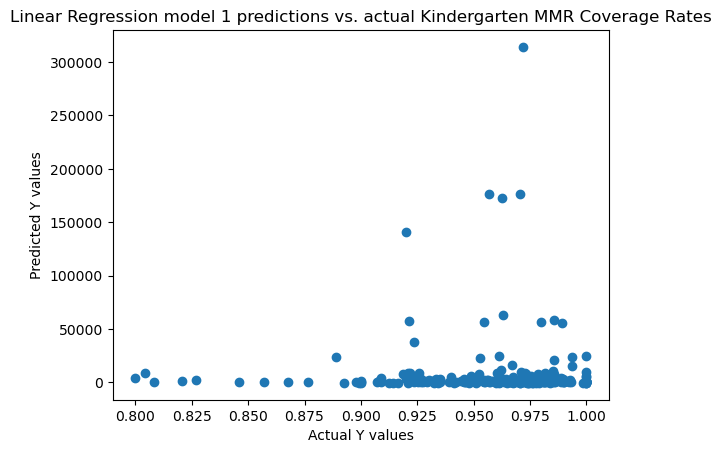

In [16]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Y values")
plt.ylabel("Predicted Y values")
plt.title("Linear Regression model 1 predictions vs. actual Kindergarten MMR Coverage Rates")
plt.show()

THis looks like a pretty poor model, doesn't seem to be much relationship at all between the actual values and predicted values, which makes sense given the R squared value was only about 5%

## OLS

In [17]:
# add constant to X_train array to perform OLS
print(f"X_train shape: {X_train.shape}")
X_train = sm.add_constant(X_train) # adds column (index 0) filled with 1’s.
print(f"X_train shape after adding constant: {X_train.shape}")
np.unique(X_train[:, 0])

X_train shape: (747, 42)
X_train shape after adding constant: (747, 43)


array([1.])

In [18]:
# add constant to other 3 arrays (X_test)
X_test = sm.add_constant(X_test)

In [19]:
ols1 = sm.OLS(y_train, X_train)
# Fit the model with fit() 
ols1_results = ols1.fit()
ols1_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.067
Date:                Tue, 09 Dec 2025   Prob (F-statistic):              0.360
Time:                        22:19:34   Log-Likelihood:                 1319.9
No. Observations:                 747   AIC:                            -2554.
Df Residuals:                     704   BIC:                            -2355.
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6084      3.421      0.470      0.638      -5.107       8.324
x1             0.0007      0.002      0.325      0.745      -0.003       0.005
x2            -0.0147      0.014     -1.062      0.289      -0.042       0.013
x3             0.0010      0.002      0.453      0.651      -0.003       0.005
x4            -0.0005      0.002     -0.231      0.818      -0.005       0.004
x5            -0.0068      0.003     -2.035      0.042      -0.013      -0.000
x6         -1.149e-05      0.003     -0.004      0.997      -0.006       0.006
x7             0.0151      0.013      1.135      0.257      -0.011       0.041
x8            -0.0002      0.002     -0.068      0.946      -0.005       0.004
x9            -0.0094      0.018     -0.518      0.604      -0.045       0.026
x10           -0.0032      0.002     -1.395      0.163      -0.008       0.001
x11           -0.0002      0.002     -0.104      0.917      -0.004       0.004
x12            0.0005      0.002      0.223      0.824      -0.004       0.005
x13           -0.0043      0.004     -1.031      0.303      -0.012       0.004
x14            0.0054      0.004      1.504      0.133      -0.002       0.012
x15            0.0679      0.045      1.506      0.132      -0.021       0.156
x16            0.0033      0.002      1.577      0.115      -0.001       0.007
x17           -0.0007      0.003     -0.262      0.793      -0.006       0.004
x18            0.0049      0.003      1.802      0.072      -0.000       0.010
x19           -0.0018      0.002     -0.789      0.430      -0.006       0.003
x20           -0.0575      0.042     -1.380      0.168      -0.139       0.024
x21            0.0066      0.007      0.876      0.381      -0.008       0.021
x22           -0.0037      0.004     -0.821      0.412      -0.012       0.005
x23           -0.0041      0.004     -1.156      0.248      -0.011       0.003
x24           -0.0022      0.008     -0.269      0.788      -0.018       0.014
x25            0.0034      0.005      0.645      0.519      -0.007       0.014
x26           -0.0324      0.024     -1.356      0.175      -0.079       0.014
x27            0.0136      0.009      1.495      0.135      -0.004       0.031
x28            0.0201      0.020      1.002      0.317      -0.019       0.059
x29           -0.0006      0.008     -0.076      0.940      -0.016       0.015
x30            0.0061      0.006      1.109      0.268      -0.005       0.017
x31           -0.0009      0.002     -0.529      0.597      -0.004       0.003
x32            0.0006      0.002      0.299      0.765      -0.003       0.005
x33            0.0014      0.005      0.267      0.790      -0.009       0.011
x34            0.0181      0.015      1.245      0.214      -0.010       0.047
x35            0.0013      0.008      0.166      0.868      -0.014       0.016
x3

In [20]:
# predict model results on X_test
y_pred = ols1_results.predict(X_test)

Text(0, 0.5, 'Predicted')

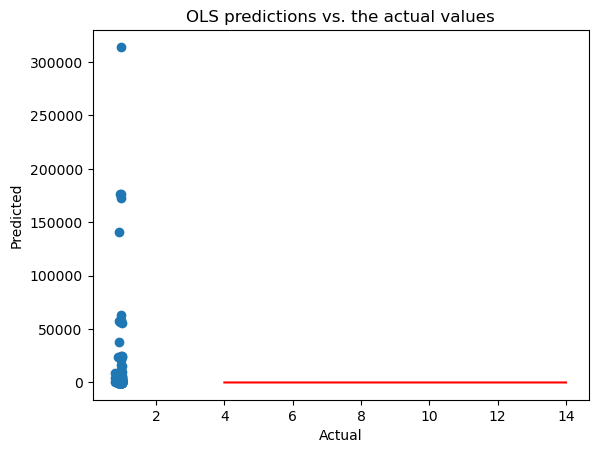

In [21]:
# Build a scatterplot
plt.scatter(y_test, y_pred)

# Add a line for perfect correlation. 
plt.plot([x for x in range(4,15)],[x for x in range(4,15)], color='red')

# Label it nicely
plt.title("OLS predictions vs. the actual values")
plt.xlabel ("Actual")
plt.ylabel("Predicted")

## Ridge

In [22]:
# set hyperparameter range
param_grid = {"alpha": [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 1000000]}
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv=kf)

In [23]:
# fit to training data
ridge_cv.fit(X_train, y_train)
# check optimal parameters
print("Tuned ridge paramaters: {}".format(ridge_cv.best_params_))
# check training score
print("Tuned ridge score: {}".format(round(math.sqrt(-ridge_cv.best_score_),5))) # negative sq root of the negative mean squared error

# print("All tuned ridge scores: {}".format(math.sqrt(-ridge_cv.scoring))) # negative sq root of the negative mean squared error

Tuned ridge paramaters: {'alpha': 10000.0}
Tuned ridge score: 0.10057


In [24]:
ridge_cv.fit(X_test, y_test)
print("Tuned ridge score: {}".format(round(math.sqrt(-ridge_cv.best_score_),5))) # negative sq root of the negative mean squared error


Tuned ridge score: 0.40756


Model did better on the test data than on the train data. Possibly it is under fitting? Curious that the best score during tuning occured when there was the largest alpha (penalty) on high coefficients which I didn't know was possible while underfitting. 

In [25]:
dir(ridge_cv)


['__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_check_feature_names',
 '_check_n_features',
 '_check_refit_for_multimetric',
 '_estimator_type',
 '_format_results',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_required_parameters',
 '_run_search',
 '_select_best_index',
 '_validate_data',
 '_validate_params',
 'best_estimator_',
 'best_index_',
 'best_params_',
 'best_score_',
 'classes_',
 'cv',
 'cv_results_',
 'decision_function',
 'error_score',
 'estimator',
 'fit',
 'get_params',
 'inverse_transform',
 'multimetric_',
 'n_fe

## XGBoost

In [59]:
xg = xgb.XGBRegressor()
# learning_rate (alias eta): Controls the step size, with smaller values preventing overfitting.
#param = {'max_depth': 2, 'eta': 1, 'objective': 'reg:squarederror'}
param_grid = {"alpha": [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 1000000],
             "max_depth": [2,6, 10, 14],
             "eta": [0.5, 1.0, 1.5]
             }


FiX: the code below ran way too fast given the # of parameters in param_grid, not sure it's tuning, pull out tuning results

In [60]:
xgboost_cv = GridSearchCV(xg, param_grid, cv=kf) 
xg.fit(X_train, y_train)
xg.score(X_test, y_test)

-36.15879482049188

<Axes: >

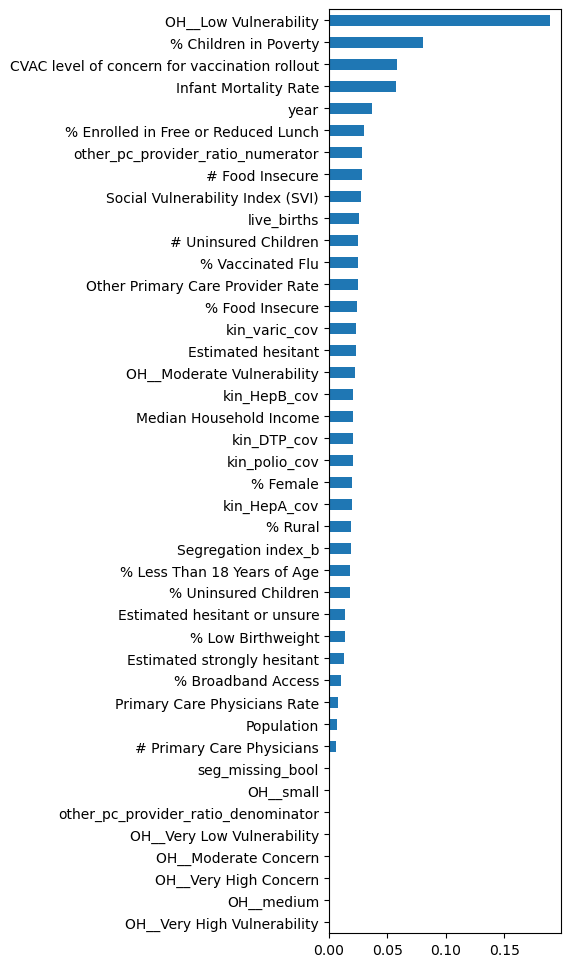

In [58]:
pd.Series(xg.feature_importances_, index=feature_names).sort_values().plot.barh(figsize=(3,12))


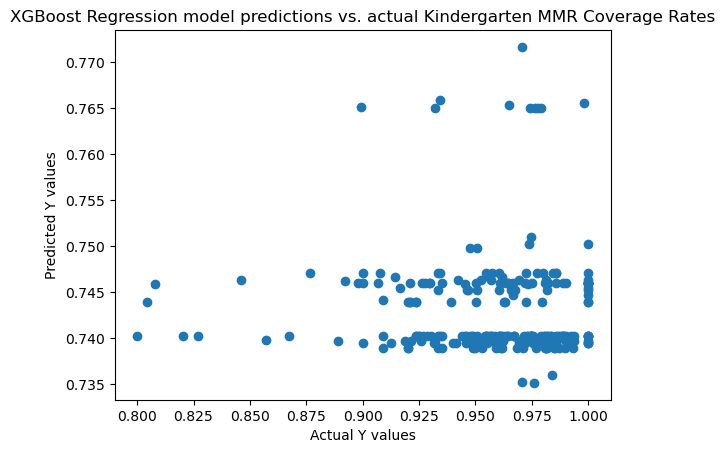

In [51]:
preds = xg.predict(X_test)

# plot scatter of predictions vs actual coverage
plt.scatter(y_test,preds)
plt.xlabel("Actual Y values")
plt.ylabel("Predicted Y values")
plt.title("XGBoost Regression model predictions vs. actual Kindergarten MMR Coverage Rates")
plt.show()

# RandomForest

In [61]:
rf = RandomForestRegressor()

In [ ]:
para
n_estimators=300, random_state = 1,n_jobs=-1

In [62]:
rf_cv = GridSearchCV(rf, param_grid, cv=kf)
rf.fit(X_train, y_train)

/var/folders/zg/81kjn_8j4692tlw3f6q33h6w0000gq/T/ipykernel_33766/1226558770.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(X_train, y_train)


-13.179883296501488

In [ ]:
rf.score(X_test, y_test)